### Get the data from this link.

https://cli.fusio.net/cli/climate_data/webdata/hly4935.csv

(This is different that the data I used in the lecture)

### Plot:

- The temperature

- The mean temperature each day

- The mean temperature for each month

60% of the marks will be given for the above

For the last 40%

Plot:

- The Windspeed (there is data missing from this column)
- The rolling windspeed (say over 24 hours)
- The max windspeed for each day
- The monthly mean of the daily max windspeeds (yer I am being nasty here)

You do not need to over comment your code. Marks will be given for how nice the plots are.

In [22]:
# Importing the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#import the dataset
datadir = 'C:\\Users\\gusgo\\OneDrive - Atlantic TU\\PFDA\\assignments\\week6\\'
filename = 'hly4935.csv'
df = pd.read_csv(datadir + filename, skiprows=23, header=0) #table starts at row 24, header is row 23
# Plot describe
df.describe()
# info
df.info()

C:\Users\gusgo\AppData\Local\Temp\ipykernel_18348\1759276945.py:9: DtypeWarning: Columns (2,10,12,14,15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(datadir + filename, skiprows=23, header=0) #table starts at row 24, header is row 23


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247674 entries, 0 to 247673
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    247674 non-null  object 
 1   ind     247674 non-null  int64  
 2   rain    247674 non-null  object 
 3   ind.1   247674 non-null  int64  
 4   temp    247674 non-null  float64
 5   ind.2   247674 non-null  int64  
 6   wetb    247674 non-null  float64
 7   dewpt   247674 non-null  float64
 8   vappr   247674 non-null  float64
 9   rhum    247674 non-null  int64  
 10  msl     247674 non-null  object 
 11  ind.3   247674 non-null  int64  
 12  wdsp    247674 non-null  object 
 13  ind.4   247674 non-null  int64  
 14  wddir   247674 non-null  object 
 15  ww      247674 non-null  object 
 16  w       247674 non-null  object 
 17  sun     247674 non-null  float64
 18  vis     247674 non-null  object 
 19  clht    247674 non-null  object 
 20  clamt   247674 non-null  object 
dtypes: float64

In [32]:
#date is object, convert to datetime
df['date'] = pd.to_datetime(df['date'])

C:\Users\gusgo\AppData\Local\Temp\ipykernel_18348\4205928148.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247674 entries, 0 to 247673
Data columns (total 21 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    247674 non-null  datetime64[ns]
 1   ind     247674 non-null  int64         
 2   rain    247674 non-null  object        
 3   ind.1   247674 non-null  int64         
 4   temp    247674 non-null  float64       
 5   ind.2   247674 non-null  int64         
 6   wetb    247674 non-null  float64       
 7   dewpt   247674 non-null  float64       
 8   vappr   247674 non-null  float64       
 9   rhum    247674 non-null  int64         
 10  msl     247674 non-null  object        
 11  ind.3   247674 non-null  int64         
 12  wdsp    247674 non-null  object        
 13  ind.4   247674 non-null  int64         
 14  wddir   247674 non-null  object        
 15  ww      247674 non-null  object        
 16  w       247674 non-null  object        
 17  sun     247674 non-null  floa

date:  -  Date and Time (utc)
rain:  -  Precipitation Amount (mm)	  
temp:  -  Air Temperature (C)	
wetb:  -  Wet Bulb Temperature (C)
dewpt: -  Dew Point Temperature (C)             
rhum:  -  Relative Humidity (%)
vappr: -  Vapour Pressure (hPa)	 
msl:   -  Mean Sea Level Pressure (hPa)
wdsp:  -  Mean Wind Speed (knot)
wddir: -  Predominant Wind Direction (degree)
ww:    -  Synop code for Present Weather
w:     -  Synop code for Past Weather
sun:   -  Sunshine duration (hours)
vis:   -  Visibility (m)
clht:  -  Cloud height (100's of ft) - 999 if none 
clamt: -  Cloud amount
ind:   -  Indicator

In [54]:
# Check the number of columns in the DataFrame
print(len(df.columns))
#df.columns = ['Date and Time (utc)', 'indicator 1', 'Precipitation Amount (mm)', 'indicator 2', 'Air Temperature (C)', 'indicator 3', 'Wet Bulb Temperature (C)','Dew Point Temperature (C)', 'Vapour Pressure (hPa)', 'Relative Humidity (%)', 'Mean Sea Level Pressure (hPa)', 'indicator 4', 'Mean Wind Speed (knot)', 'indicator 5', 'Predominant Wind Direction (degree)', 'Synop code for Present Weather', 'Synop code for Past Weather', 'Visibility (m)', 'Cloud height (100s of ft)-999 if none','Cloud amount']
# Change header names to match the instructions on the CSV file
df.columns = ['Date and Time (utc)', 'indicator 1', 'Precipitation Amount (mm)', 'indicator 2', 'Air Temperature (C)', 'indicator 3', 'Wet Bulb Temperature (C)', 'Dew Point Temperature (C)', 'Relative Humidity (%)', 'Vapour Pressure (hPa)', 'Mean Sea Level Pressure (hPa)', 'indicator 4', 'Mean Wind Speed (knot)', 'indicator 5', 'Predominant Wind Direction (degree)', 'Synop code for Present Weather', 'Synop code for Past Weather','Sunshine duration (hours)', 'Visibility (m)', 'Cloud height (100s of ft)-999 if none', 'Cloud amount']
df.info()



21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247674 entries, 0 to 247673
Data columns (total 21 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   Date and Time (utc)                    247674 non-null  datetime64[ns]
 1   indicator 1                            247674 non-null  int64         
 2   Precipitation Amount (mm)              247674 non-null  object        
 3   indicator 2                            247674 non-null  int64         
 4   Air Temperature (C)                    247674 non-null  float64       
 5   indicator 3                            247674 non-null  int64         
 6   Wet Bulb Temperature (C)               247674 non-null  float64       
 7   Dew Point Temperature (C)              247674 non-null  float64       
 8   Relative Humidity (%)                  247674 non-null  float64       
 9   Vapour Pressure (hPa)                  247674

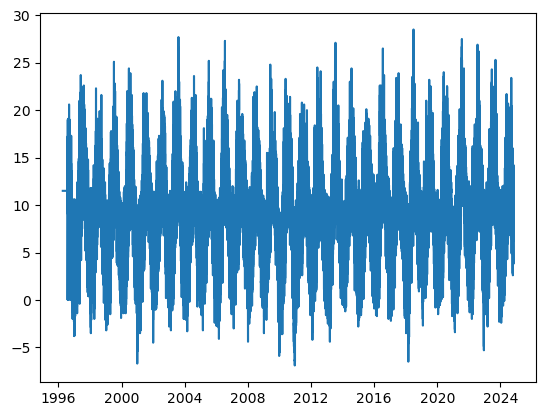

In [56]:
# plot temperature per date graphically
plt.plot(df['Date and Time (utc)'], df['Air Temperature (C)'])

Text(0.5, 1.0, 'Mean Air Temperature by Month')

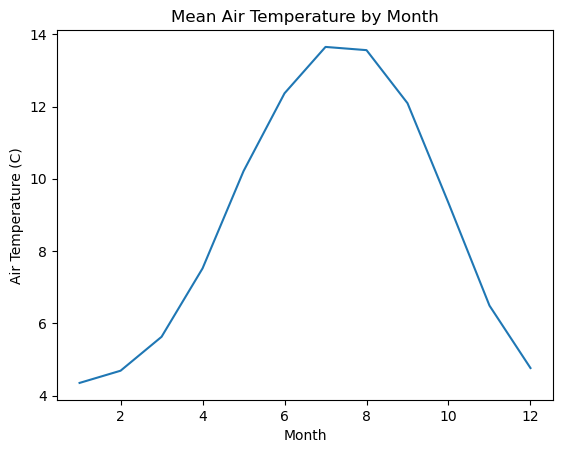

In [82]:
#plot another graphic of mean temperature by month label as temperature
df.groupby('month')['Air Temperature (C)'].mean().plot()
plt.ylabel('Air Temperature (C)')
plt.xlabel('Month')
plt.title('Mean Air Temperature by Month')

Text(0.5, 1.0, 'Mean Air Temperature by Day')

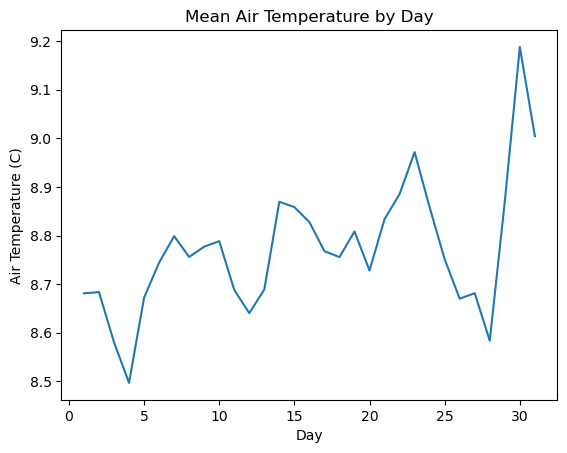

In [83]:
#plot another graphic of mean temperature by month label as temperature
df.groupby('day')['Air Temperature (C)'].mean().plot()
plt.ylabel('Air Temperature (C)')
plt.xlabel('Day')
plt.title('Mean Air Temperature by Day')

Text(0.5, 1.0, 'Mean Wind Speed by Year')

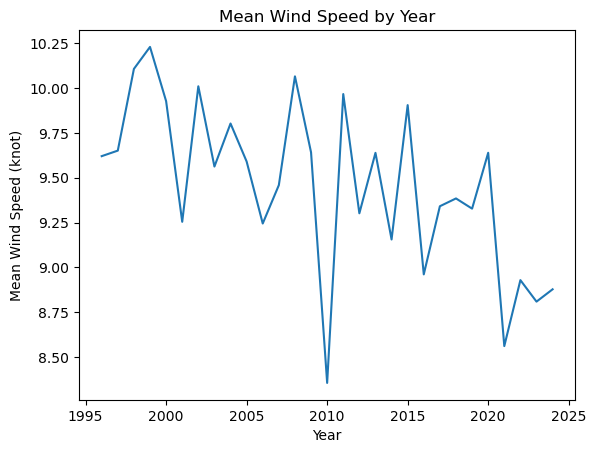

In [ ]:
# Extract year from 'Date and Time (utc)' and create a new 'year' column

df['year'] = df['Date and Time (utc)'].dt.year

# Convert 'Mean Wind Speed (knot)' to numeric, coercing errors to NaN

df['Mean Wind Speed (knot)'] = pd.to_numeric(df['Mean Wind Speed (knot)'], errors='coerce')
df = df.dropna(subset=['Mean Wind Speed (knot)'])
df.groupby('year')['Mean Wind Speed (knot)'].mean().plot()

plt.ylabel('Mean Wind Speed (knot)')
plt.xlabel('Year')
plt.title('Mean Wind Speed by Year')

Text(0, 0.5, 'Mean Temperature by Day')

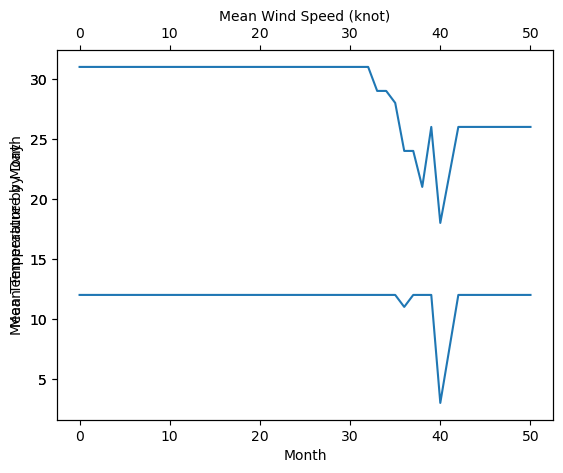

In [115]:
#plot the max wind speed by day
ax1 = df.groupby('Mean Wind Speed (knot)')['month'].max().plot()
ax1.set_ylabel('Mean Temperature by Month')
ax1.set_xlabel('Month')
#show a table with the max wind speed by day
ax2 = ax1.twiny()
ax2 = df.groupby('Mean Wind Speed (knot)')['day'].max().plot()
ax2.set_ylabel('Mean Temperature by Day')
#use 2 refrences

